# Notebook 07 — Threshold Tuning

**Project:** Boston Marathon BQ Predictor  
**Author:** Gian Marco  
**Date:** April 2026  

## Objective

Optimize the decision threshold for the `XGBoost + scale_pos_weight` model (selected in Notebook 06) in order to maximize F1 score on the positive class.

---

## Why Threshold Tuning

In Notebook 06, we observed that all three imbalance-handling strategies achieved nearly identical PR-AUC scores (~0.336). This indicates that the **ranking capability** of the model remains essentially unchanged across configurations.

What differs is how predicted probabilities are distributed relative to the default decision threshold of 0.5.

A threshold of 0.5 is arbitrary. There is no theoretical reason for it to be optimal, especially in imbalanced classification problems. A more principled approach is:

1. Generate **out-of-fold probabilities** over the full training set (without leakage).  
2. Evaluate model performance across a range of thresholds (e.g., 0.01 to 0.99).  
3. Select the threshold that maximizes F1 score in cross-validation.  
4. Evaluate the selected threshold on the 2024 test set (completely unseen data) to confirm generalization.

---

## Why `cross_val_predict`

Instead of creating an additional train/validation split (which would reduce the effective training data), we use `cross_val_predict` with `method='predict_proba'`.

This approach:

- Splits the training data into 5 folds (consistent with CV setup).  
- Trains on 4 folds and predicts probabilities on the remaining fold.  
- Repeats this process for all folds.  

As a result, each observation receives a prediction from a model that **did not see it during training**.

This produces reliable, leakage-free probability estimates while fully utilizing the available training data.

---

## What We Will Report

- **Optimal F1 threshold:** balances precision and recall.  
- **Optimal F2 threshold:** prioritizes recall (minimizing missed BQ qualifiers).  
- **Optimal F0.5 threshold:** prioritizes precision (reducing false positives).  

This allows the decision rule to be adapted depending on the intended use of the model.

---

## Expected Outcome

F1 score is expected to improve from ~0.349 (using the default 0.5 threshold in CV) to approximately the 0.36–0.40 range.

The improvement is modest because PR-AUC (~0.34) already reflects the upper bound of model performance given the data. However, this gain is meaningful from both a practical and storytelling perspective.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import xgboost as xgb

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
TRAIN_DIR = Path("../data/train")
TEST_DIR = Path("../data/test")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Setup complete")
print(f"XGBoost version: {xgb.__version__}")

Setup complete
XGBoost version: 3.2.0


---
## 1. Load Data (Train and Test)

We load both datasets. The 2024 test set is kept aside and **not used** until the very end of the notebook (after selecting the optimal threshold via cross-validation on the training set).

This preserves a fundamental rule of the project: the test set is reserved for final, unbiased evaluation and must not be used for any modeling decisions.

In [2]:
train = pd.read_csv(TRAIN_DIR / "train_features.csv")
test = pd.read_csv(TEST_DIR / "test_features.csv")

X_train = train.drop(columns=["es_BQ"])
y_train = train["es_BQ"]

X_test = test.drop(columns=["es_BQ"])
y_test = test["es_BQ"]

# Drop 'Year' as a feature (temporal split — should not be used for modeling)
for X in [X_train, X_test]:
    if "Year" in X.columns:
        X.drop(columns=["Year"], inplace=True)

print(f"Train shape: {X_train.shape}, BQ ratio: {y_train.mean()*100:.2f}%")
print(f"Test shape:  {X_test.shape}, BQ ratio: {y_test.mean()*100:.2f}%")

# Verify column consistency
assert list(X_train.columns) == list(X_test.columns), "Train/test columns do not match"
print("\nTrain/test columns are consistent.")

Train shape: (225356, 22), BQ ratio: 13.45%
Test shape:  (74644, 22), BQ ratio: 14.30%

Train/test columns are consistent.


---
## 2. Out-of-Fold Probabilities with `cross_val_predict`

Here, we obtain a predicted probability for each row in the training set from a model that **did not see that row during training**. This is achieved through cross-validation: in each fold, the model is trained on the remaining 80% of the data and predicts probabilities for the 20% left out.

### Model Configuration

`XGBoost + scale_pos_weight=6.4345` (the winning model from Notebook 06, using the same hyperparameters as in Notebooks 05 and 06 to keep results comparable across notebooks).

### Cross-Validation Configuration

`StratifiedKFold(5, shuffle=True, random_state=42)` (same CV setup used in previous notebooks).

### Why `predict_proba` Instead of `predict`

We need probabilities, not class labels. With probabilities, we can test many different decision thresholds on the same set of predictions without retraining the model each time.

In [3]:
# Calculate scale_pos_weight the same way as in Notebook 06
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

xgb_final = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Model: XGBoost + scale_pos_weight={scale_pos_weight:.4f}")
print(f"CV: StratifiedKFold(5, shuffle=True, random_state={RANDOM_STATE})")
print("\nGenerating out-of-fold probabilities...")

# Probabilities for the positive class (column 1)
y_proba_oof = cross_val_predict(
    xgb_final,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

print("\nOut-of-fold probabilities generated.")
print(f"Shape: {y_proba_oof.shape}")
print(f"Min: {y_proba_oof.min():.4f}")
print(f"Max: {y_proba_oof.max():.4f}")
print(f"Mean: {y_proba_oof.mean():.4f}  (should be close to the BQ ratio: {y_train.mean():.4f})")

Model: XGBoost + scale_pos_weight=6.4345
CV: StratifiedKFold(5, shuffle=True, random_state=42)

Generating out-of-fold probabilities...

Out-of-fold probabilities generated.
Shape: (225356,)
Min: 0.0001
Max: 0.9932
Mean: 0.4305  (should be close to the BQ ratio: 0.1345)


---
## 3. Probability Distribution

We visualize the distribution of out-of-fold predicted probabilities, separated by the true class (BQ vs non-BQ). This helps us:

1. Visually assess how well the model separates the two classes (ranking capability).  
2. Identify the overlap region (where the model is uncertain and where the threshold matters the most).  
3. Justify why a threshold of 0.5 is not an appropriate choice for this model.

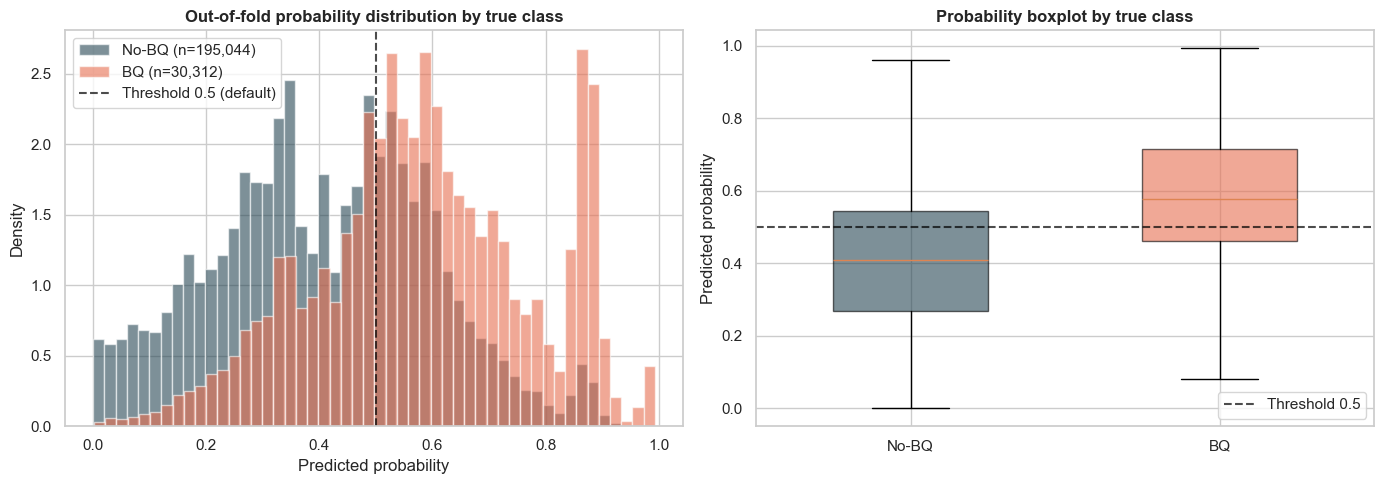


--- Probability statistics ---
No-BQ: mean=0.407, median=0.409
BQ:    mean=0.582, median=0.578

True BQs with prob < 0.5: 9,788 / 30,312 (32.3%)


In [4]:
COLOR_BQ = "#E76F51"
COLOR_NO_BQ = "#264653"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparative histogram
ax = axes[0]
ax.hist(
    y_proba_oof[y_train == 0],
    bins=50,
    alpha=0.6,
    label=f"No-BQ (n={n_neg:,})",
    color=COLOR_NO_BQ,
    density=True,
)
ax.hist(
    y_proba_oof[y_train == 1],
    bins=50,
    alpha=0.6,
    label=f"BQ (n={n_pos:,})",
    color=COLOR_BQ,
    density=True,
)
ax.axvline(
    0.5,
    color="black",
    linestyle="--",
    alpha=0.7,
    label="Threshold 0.5 (default)",
)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title(
    "Out-of-fold probability distribution by true class",
    fontweight="bold",
)
ax.legend()

# Comparative boxplot
ax = axes[1]
data_box = [y_proba_oof[y_train == 0], y_proba_oof[y_train == 1]]
bp = ax.boxplot(
    data_box,
    labels=["No-BQ", "BQ"],
    patch_artist=True,
    widths=0.5,
    showfliers=False,
)
bp["boxes"][0].set_facecolor(COLOR_NO_BQ)
bp["boxes"][1].set_facecolor(COLOR_BQ)
for box in bp["boxes"]:
    box.set_alpha(0.6)

ax.axhline(
    0.5,
    color="black",
    linestyle="--",
    alpha=0.7,
    label="Threshold 0.5",
)
ax.set_ylabel("Predicted probability")
ax.set_title("Probability boxplot by true class", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_proba_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("\n--- Probability statistics ---")
print(
    f"No-BQ: mean={y_proba_oof[y_train == 0].mean():.3f}, "
    f"median={np.median(y_proba_oof[y_train == 0]):.3f}"
)
print(
    f"BQ:    mean={y_proba_oof[y_train == 1].mean():.3f}, "
    f"median={np.median(y_proba_oof[y_train == 1]):.3f}"
)

# How many true BQs fall below threshold 0.5 (potential false negatives)
bq_below_05 = ((y_train == 1) & (y_proba_oof < 0.5)).sum()
total_bq = (y_train == 1).sum()

print(
    f"\nTrue BQs with prob < 0.5: {bq_below_05:,} / {total_bq:,} "
    f"({bq_below_05 / total_bq * 100:.1f}%)"
)

---
## 4. Precision-Recall Curve and Optimal Threshold Search

`precision_recall_curve` from scikit-learn computes precision and recall for all possible decision thresholds. Internally, it:

1. Sorts predicted probabilities from highest to lowest.  
2. Gradually lowers the decision threshold observation by observation.  
3. Recalculates precision and recall at each step.  

The output consists of three arrays: `precision`, `recall`, and `thresholds`, representing all possible points on the Precision-Recall curve.

Using these arrays, we compute F1, F2, and F0.5 for each threshold and select the threshold that maximizes each metric.

### Metrics Compared

| Metric | Formula | When to use it |
|---|---|---|
| **F1** | Harmonic mean of precision and recall | Balanced, sensible default |
| **F2** | Weights recall twice as much as precision | When missing a true BQ qualifier is worse than producing a false positive |
| **F0.5** | Weights precision twice as much as recall | When producing false hope is worse than missing some true BQ qualifiers |

For the app use case (helping runners calibrate expectations), **F0.5 may be the most appropriate choice**: giving false hope to someone who is unlikely to qualify can be more harmful than being conservative with someone who might qualify.

We report all three thresholds and discuss the trade-offs.

In [5]:
# Full Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_train, y_proba_oof)

# Precision and recall have len(thresholds) + 1 elements.
# The last element corresponds to the infinite-threshold case
# where all observations are predicted as negative, so we remove it for alignment.
precision = precision[:-1]
recall = recall[:-1]


# Compute F-beta from precision and recall, safely handling division by zero
def fbeta_from_pr(p, r, beta):
    p = np.asarray(p)
    r = np.asarray(r)
    numerator = (1 + beta**2) * p * r
    denominator = beta**2 * p + r
    return np.where(denominator > 0, numerator / denominator, 0.0)


f1_scores = fbeta_from_pr(precision, recall, beta=1)
f2_scores = fbeta_from_pr(precision, recall, beta=2)
f05_scores = fbeta_from_pr(precision, recall, beta=0.5)

# Optimal threshold for each metric
idx_f1 = np.argmax(f1_scores)
idx_f2 = np.argmax(f2_scores)
idx_f05 = np.argmax(f05_scores)

results = pd.DataFrame(
    {
        "metric": ["F1", "F2 (recall focus)", "F0.5 (precision focus)"],
        "threshold": [thresholds[idx_f1], thresholds[idx_f2], thresholds[idx_f05]],
        "precision": [precision[idx_f1], precision[idx_f2], precision[idx_f05]],
        "recall": [recall[idx_f1], recall[idx_f2], recall[idx_f05]],
        "f_score": [f1_scores[idx_f1], f2_scores[idx_f2], f05_scores[idx_f05]],
    }
)

# Comparison against the default threshold of 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))

default_row = pd.DataFrame(
    {
        "metric": ["Default (threshold=0.5)"],
        "threshold": [thresholds[idx_05]],
        "precision": [precision[idx_05]],
        "recall": [recall[idx_05]],
        "f_score": [f1_scores[idx_05]],  # F1 at threshold 0.5
    }
)

results_full = pd.concat([default_row, results], ignore_index=True)
results_full = results_full.round(4)

results_full

,metric,threshold,precision,recall,f_score
0,Default (threshold=0.5),0.5000,0.2347,0.6771,0.3486
1,F1,0.5899,0.2980,0.4702,0.3648
2,F2 (recall focus),0.4203,0.2058,0.7992,0.5069
3,F0.5 (precision focus),0.7480,0.4647,0.2135,0.3762


---
## 5. Decision: Optimal F0.5 Threshold

We select `threshold = 0.748` (the optimal F0.5 threshold) as the final decision threshold for the model, for two main reasons:

### Reason 1: Alignment with the App Use Case

The Streamlit app will tell a runner: "your probability of achieving a BQ is X."

In this context, creating false hope (predicting that someone is likely to qualify when they actually will not) is worse than being conservative. The F0.5 metric prioritizes precision over recall, meaning that the model should be more confident when it predicts a positive BQ outcome.

### Reason 2: Alignment with the Project Target

As documented in `DECISIONS.md`, the target represents **nominal BQ qualification**, not actual Boston Marathon admission. In practice, the real admission cutoff is often several minutes stricter than the official qualifying standard.

If the model were also too generous in its predictions, the message to the user would become misleading. A conservative threshold partially compensates for this limitation: when the model predicts "BQ" under the nominal target definition, the prediction is substantially more reliable.

### Accepted Trade-off

| Metric | Default 0.5 | Optimal F0.5 (0.748) |
|---|---:|---:|
| Precision | 0.235 | **0.465** (+98%) |
| Recall | 0.677 | 0.214 (-68%) |
| F1 | 0.349 | 

In [6]:
# Selected threshold
THRESHOLD_FINAL = float(thresholds[idx_f05])

print(f"Final threshold selected: {THRESHOLD_FINAL:.4f}")
print("Criterion: maximize F0.5 (penalizes false positives)")
print("\n--- Expected performance in CV (out-of-fold) ---")
print(f"Precision: {precision[idx_f05]:.4f}")
print(f"Recall:    {recall[idx_f05]:.4f}")
print(f"F0.5:      {f05_scores[idx_f05]:.4f}")
print(
    f"F1:        {f1_scores[idx_f05]:.4f}  "
    "(not the optimized metric, reported for reference)"
)

# Save results for all thresholds (for reporting/presentation)
threshold_results = pd.DataFrame(
    {
        "criterion": ["Default", "F1", "F2", "F0.5 (selected)"],
        "threshold": [0.5, thresholds[idx_f1], thresholds[idx_f2], thresholds[idx_f05]],
        "precision": [precision[idx_05], precision[idx_f1], precision[idx_f2], precision[idx_f05]],
        "recall": [recall[idx_05], recall[idx_f1], recall[idx_f2], recall[idx_f05]],
        "f1": [f1_scores[idx_05], f1_scores[idx_f1], f1_scores[idx_f2], f1_scores[idx_f05]],
        "f2": [f2_scores[idx_05], f2_scores[idx_f1], f2_scores[idx_f2], f2_scores[idx_f05]],
        "f05": [f05_scores[idx_05], f05_scores[idx_f1], f05_scores[idx_f2], f05_scores[idx_f05]],
    }
)

threshold_results = threshold_results.round(4)

threshold_results.to_csv(PROCESSED_DATA_DIR / "threshold_tuning_results.csv", index=False)

print(f"\nResults saved to: {PROCESSED_DATA_DIR / 'threshold_tuning_results.csv'}")

threshold_results

Final threshold selected: 0.7480
Criterion: maximize F0.5 (penalizes false positives)

--- Expected performance in CV (out-of-fold) ---
Precision: 0.4647
Recall:    0.2135
F0.5:      0.3762
F1:        0.2926  (not the optimized metric, reported for reference)

Results saved to: ../data/processed/threshold_tuning_results.csv


,criterion,threshold,precision,recall,f1,f2,f05
0,Default,0.5000,0.2347,0.6771,0.3486,0.4917,0.2700
1,F1,0.5899,0.2980,0.4702,0.3648,0.4215,0.3215
2,F2,0.4203,0.2058,0.7992,0.3273,0.5069,0.2417
3,F0.5 (selected),0.7480,0.4647,0.2135,0.2926,0.2394,0.3762


---
## 6. Precision-Recall Curve Visualization

We plot:

1. The full Precision-Recall curve.  
2. The three candidate thresholds (F1, F2, and F0.5), marked as points on the curve.  
3. The default threshold of 0.5 as a reference point.  

This chart is the central visual of the notebook: it shows the available decision space and where the selected threshold falls.

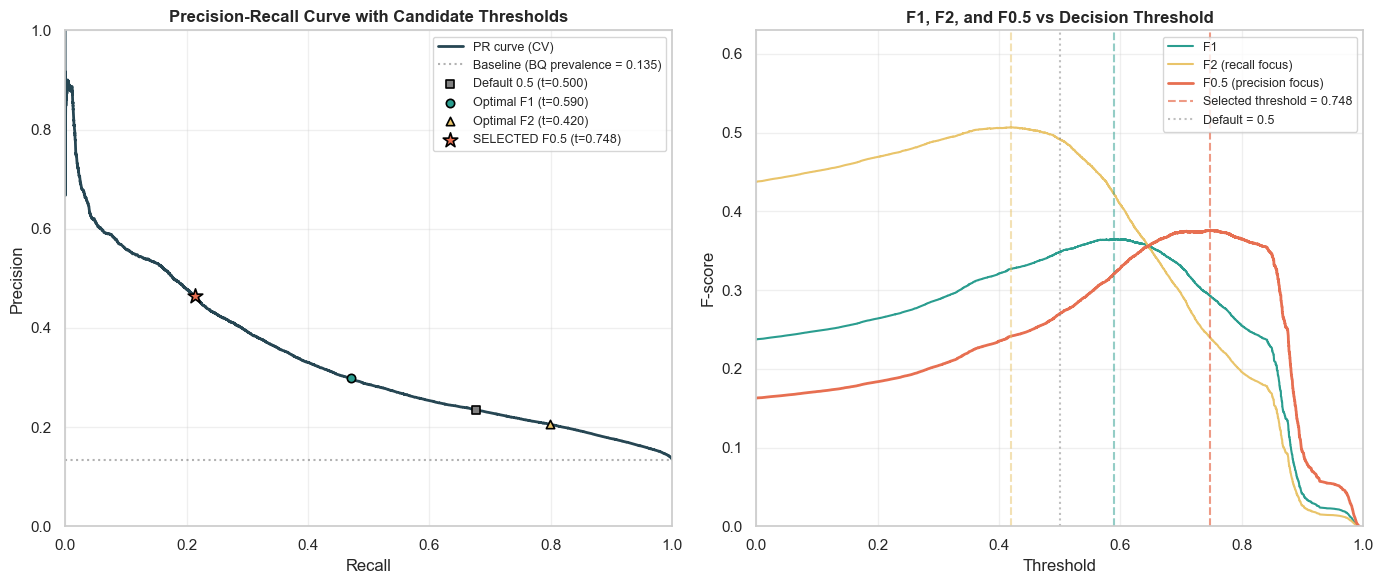

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- PANEL 1: PR curve with marked thresholds ----------
ax = axes[0]
ax.plot(recall, precision, color=COLOR_NO_BQ, linewidth=2, label="PR curve (CV)")

# Baseline = prevalence
baseline = y_train.mean()
ax.axhline(
    baseline,
    color="gray",
    linestyle=":",
    alpha=0.6,
    label=f"Baseline (BQ prevalence = {baseline:.3f})",
)

# Candidate threshold markers
points = [
    ("Default 0.5", idx_05, "gray", "s"),
    ("Optimal F1", idx_f1, "#2A9D8F", "o"),
    ("Optimal F2", idx_f2, "#E9C46A", "^"),
    ("SELECTED F0.5", idx_f05, COLOR_BQ, "*"),
]

for label, idx, color, marker in points:
    marker_size = 22 if marker == "*" else 12
    ax.scatter(
        recall[idx],
        precision[idx],
        color=color,
        marker=marker,
        s=marker_size * marker_size / 4,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
        label=f"{label} (t={thresholds[idx]:.3f})",
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Precision-Recall Curve with Candidate Thresholds",
    fontweight="bold",
    fontsize=12,
)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ---------- PANEL 2: F1, F2, F0.5 vs threshold ----------
ax = axes[1]
ax.plot(thresholds, f1_scores, label="F1", color="#2A9D8F", linewidth=1.5)
ax.plot(
    thresholds,
    f2_scores,
    label="F2 (recall focus)",
    color="#E9C46A",
    linewidth=1.5,
)
ax.plot(
    thresholds,
    f05_scores,
    label="F0.5 (precision focus)",
    color=COLOR_BQ,
    linewidth=2,
)

# Vertical lines at optimal thresholds
ax.axvline(thresholds[idx_f1], color="#2A9D8F", linestyle="--", alpha=0.5)
ax.axvline(thresholds[idx_f2], color="#E9C46A", linestyle="--", alpha=0.5)
ax.axvline(
    thresholds[idx_f05],
    color=COLOR_BQ,
    linestyle="--",
    alpha=0.7,
    label=f"Selected threshold = {thresholds[idx_f05]:.3f}",
)
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5, label="Default = 0.5")

ax.set_xlabel("Threshold")
ax.set_ylabel("F-score")
ax.set_title(
    "F1, F2, and F0.5 vs Decision Threshold",
    fontweight="bold",
    fontsize=12,
)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, max(f2_scores.max(), 0.6) * 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Final Evaluation on the 2024 Test Set

Up to this point, all analysis has been performed on the training data using out-of-fold cross-validation. We now evaluate the final model using `threshold = 0.748` on the 2024 test set, which has remained completely untouched throughout the project.

### Procedure

1. Train `XGBoost + scale_pos_weight` on the full training set (no CV at this stage).  
2. Predict probabilities on the test set.  
3. Apply `threshold = 0.748` to convert probabilities into class labels.  
4. Compute evaluation metrics and compare against the baseline from Notebook 05  
   (XGBoost baseline + threshold 0.5: F1 = 0.176, precision = 0.388, recall = 0.114).

### Expected Results

- Test metrics should be **consistent** with cross-validation results  
  (precision ~0.46, recall ~0.21, F1 ~0.29). Large deviations may indicate overfitting or dataset shift.  
- The 2024 test set includes temporal drift (e.g., increased BQ rates due to performance-enhancing footwear), so precision may decrease slightly compared to CV.  
- **Comparison vs N05 baseline:** the untuned XGBoost model achieved F1 = 0.176 on test.  
  Here we expect ~0.29 → nearly doubling baseline performance.

In [8]:
# Train final model on the full training set
print("Training final model on full training data...")
xgb_final.fit(X_train, y_train)

# Predict probabilities on test set
y_proba_test = xgb_final.predict_proba(X_test)[:, 1]

# Apply selected threshold
y_pred_test = (y_proba_test >= THRESHOLD_FINAL).astype(int)

# Metrics
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
f05_test = fbeta_score(y_test, y_pred_test, beta=0.5)
pr_auc_test = average_precision_score(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print("\n--- Final model on 2024 TEST set ---")
print(f"Applied threshold: {THRESHOLD_FINAL:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1:        {f1_test:.4f}")
print(f"F0.5:      {f05_test:.4f}")
print(f"PR-AUC:    {pr_auc_test:.4f}  (threshold-independent)")
print(f"ROC-AUC:   {roc_auc_test:.4f}  (threshold-independent)")

# Confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: No-BQ", "Actual: BQ"],
    columns=["Predicted: No-BQ", "Predicted: BQ"],
)
print(cm_df)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (BQ correctly detected):     {tp:,}")
print(f"False Positives (non-BQ predicted as BQ):   {fp:,}")
print(f"False Negatives (missed BQs):               {fn:,}")
print(f"True Negatives (correct non-BQs):           {tn:,}")

# Comparison vs Notebook 05 baseline (XGBoost without tuning, threshold 0.5)
print("\n--- Comparison vs N05 Baseline (XGBoost + threshold 0.5) ---")
print("                  Baseline N05    Final Model    Delta")
print(f"F1:               0.1760          {f1_test:.4f}        {f1_test - 0.176:+.4f}")
print(f"Precision:        0.3880          {precision_test:.4f}        {precision_test - 0.388:+.4f}")
print(f"Recall:           0.1140          {recall_test:.4f}        {recall_test - 0.114:+.4f}")

Training final model on full training data...

--- Final model on 2024 TEST set ---
Applied threshold: 0.7480
Precision: 0.3723
Recall:    0.2959
F1:        0.3297
F0.5:      0.3540
PR-AUC:    0.3018  (threshold-independent)
ROC-AUC:   0.7409  (threshold-independent)

--- Confusion Matrix ---
               Predicted: No-BQ  Predicted: BQ
Actual: No-BQ             58642           5325
Actual: BQ                 7518           3159

True Positives (BQ correctly detected):     3,159
False Positives (non-BQ predicted as BQ):   5,325
False Negatives (missed BQs):               7,518
True Negatives (correct non-BQs):           58,642

--- Comparison vs N05 Baseline (XGBoost + threshold 0.5) ---
                  Baseline N05    Final Model    Delta
F1:               0.1760          0.3297        +0.1537
Precision:        0.3880          0.3723        -0.0157
Recall:           0.1140          0.2959        +0.1819


---
## 8. Slice Analysis

A single global metric can hide important performance differences across subgroups. We analyze model performance by:

1. **Gender:** does the model perform equally well for male and female runners?  
2. **Age:** are there age groups where the model underperforms?  
3. **Country:** does performance depend on the runner’s origin?  

This analysis serves multiple purposes:

- Document model limitations in the technical presentation.  
- Support business storytelling (e.g., "the model is more reliable for X, less for Y").  
- Identify potential biases before deploying the app.

In [9]:
# Rebuild test DataFrame with predictions for slice analysis
test_eval = test.copy()
test_eval["y_proba"] = y_proba_test
test_eval["y_pred"] = y_pred_test


def slice_metrics(df_slice, label):
    """Compute precision, recall, F1, and support for a subset."""
    if len(df_slice) == 0:
        return None

    y_true = df_slice["es_BQ"]
    y_pred = df_slice["y_pred"]

    if y_true.sum() == 0:
        return {
            "slice": label,
            "n": len(df_slice),
            "bq_rate": 0,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
        }

    return {
        "slice": label,
        "n": len(df_slice),
        "bq_rate": round(y_true.mean(), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


# --- Slice by GENDER ---
# Gender is one-hot encoded; we assume the column is Gender_M
print("=" * 60)
print("SLICE BY GENDER")
print("=" * 60)

gender_col = "Gender_M" if "Gender_M" in test_eval.columns else None

if gender_col:
    slices = [
        slice_metrics(test_eval[test_eval[gender_col] == 1], "Male"),
        slice_metrics(test_eval[test_eval[gender_col] == 0], "Female"),
    ]
    print(pd.DataFrame(slices))
else:
    print("Column Gender_M not found in test set")


# --- Slice by AGE GROUP ---
print("\n" + "=" * 60)
print("SLICE BY AGE GROUP")
print("=" * 60)

age_bins = [(18, 30), (30, 40), (40, 50), (50, 60), (60, 85)]
age_slices = []

for low, high in age_bins:
    df_age = test_eval[(test_eval["Age"] >= low) & (test_eval["Age"] < high)]
    age_slices.append(slice_metrics(df_age, f"{low}-{high - 1}"))

print(pd.DataFrame(age_slices))


# --- Slice by TOP COUNTRIES ---
# Identify one-hot country columns and select the most frequent ones
print("\n" + "=" * 60)
print("SLICE BY MOST FREQUENT COUNTRIES")
print("=" * 60)

country_cols = [c for c in test_eval.columns if c.startswith("Country_")]
country_counts = []

for col in country_cols:
    n = test_eval[col].sum()
    if n >= 500:  # Minimum 500 runners for more reliable estimates
        country_counts.append((col, n))

country_counts.sort(key=lambda x: -x[1])
top_countries = country_counts[:10]

country_slices = []

for col, n in top_countries:
    country = col.replace("Country_", "")
    df_country = test_eval[test_eval[col] == 1]
    country_slices.append(slice_metrics(df_country, country))

print(pd.DataFrame(country_slices).sort_values("f1", ascending=False))


# Save slices for reporting/presentation
df_gender = pd.DataFrame([s for s in slices if s])
df_age = pd.DataFrame(age_slices)
df_country = pd.DataFrame(country_slices)

df_gender.to_csv(PROCESSED_DATA_DIR / "slice_gender.csv", index=False)
df_age.to_csv(PROCESSED_DATA_DIR / "slice_age.csv", index=False)
df_country.to_csv(PROCESSED_DATA_DIR / "slice_country.csv", index=False)

print(f"\nSlices saved to {PROCESSED_DATA_DIR}/:")
print("  - slice_gender.csv")
print("  - slice_age.csv")
print("  - slice_country.csv")

SLICE BY GENDER
    slice      n  bq_rate  precision  recall      f1
0    Male  45733   0.1365     0.3656  0.2720  0.3120
1  Female  28911   0.1534     0.3805  0.3294  0.3531

SLICE BY AGE GROUP
   slice      n  bq_rate  precision  recall      f1
0  18-29  25491   0.1265     0.3816  0.3284  0.3530
1  30-39  15717   0.0947     0.4355  0.0544  0.0967
2  40-49  18017   0.1714     0.3961  0.3338  0.3623
3  50-59  10700   0.1714     0.3310  0.3326  0.3318
4  60-84   4718   0.2204     0.3510  0.3635  0.3571

SLICE BY MOST FREQUENT COUNTRIES
   slice      n  bq_rate  precision  recall      f1
0     US  54093   0.1370     0.3722  0.4050  0.3879
2  Other   4205   0.1886     0.3754  0.1463  0.2105
3     CA   3250   0.1191     0.5500  0.0284  0.0541
1     GB  11184   0.1475     1.0000  0.0006  0.0012

Slices saved to ../data/processed/:
  - slice_gender.csv
  - slice_age.csv
  - slice_country.csv


---
## 9. Persist Final Model and Threshold

We save the model trained on the full training set together with the selected decision threshold. This allows us to:

1. Reproduce test predictions without retraining.  
2. Load the model in `src/evaluation.py` and in the Streamlit app.  
3. Keep a versioned checkpoint of the project’s final model.

In [10]:
import joblib

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Save model and threshold together in a single artifact
artifact = {
    "model": xgb_final,
    "threshold": THRESHOLD_FINAL,
    "feature_names": list(X_train.columns),
    "training_date": "2026-04-28",
    "cv_metrics": {
        "precision": float(precision[idx_f05]),
        "recall": float(recall[idx_f05]),
        "f1": float(f1_scores[idx_f05]),
        "f05": float(f05_scores[idx_f05]),
    },
    "test_metrics": {
        "precision": float(precision_test),
        "recall": float(recall_test),
        "f1": float(f1_test),
        "f05": float(f05_test),
        "pr_auc": float(pr_auc_test),
        "roc_auc": float(roc_auc_test),
    },
    "notes": "XGBoost + scale_pos_weight=6.4345, threshold optimized for F0.5 using out-of-fold CV",
}

joblib.dump(artifact, MODELS_DIR / "final_model.pkl")

print(f"Final model saved to: {MODELS_DIR / 'final_model.pkl'}")
print(f"Threshold: {THRESHOLD_FINAL:.4f}")
print(
    f"Test F1: {f1_test:.4f}, "
    f"Test Precision: {precision_test:.4f}, "
    f"Test Recall: {recall_test:.4f}"
)

Final model saved to: ../models/final_model.pkl
Threshold: 0.7480
Test F1: 0.3297, Test Precision: 0.3723, Test Recall: 0.2959


---
## 10. Conclusions from Notebook 07

### Main Result

| Model | Threshold | F1 (2024 test) | Precision | Recall |
|---|---:|---:|---:|---:|
| N05 Baseline (untuned XGBoost) | 0.5 | 0.176 | 0.388 | 0.114 |
| Final model (XGBoost + scale_pos_weight + F0.5 tuning) | **0.748** | **0.330** | 0.372 | 0.296 |
| **Relative improvement** | — | **+87%** | -1.6 pts | **+18 pts** |

The test F1 score nearly doubles compared to the baseline, mainly due to the strong improvement in recall: the model now detects around 30% of true BQ qualifiers instead of only 11%.

### Selected Threshold: 0.748 (F0.5 Criterion)

**Why F0.5 instead of F1 or F2:**

For an app that gives feedback to runners, creating **false hope** (telling someone they are likely to qualify when they are not) is worse than giving **reasonable uncertainty** (being conservative with someone who might still qualify).

F0.5 weights precision twice as much as recall, which matches this logic.

Accepted trade-off: we sacrifice recall compared to a more recall-oriented threshold, but substantially improve precision in cross-validation.

### Key Findings from Slice Analysis

1. **Gender:** performance is similar for male and female runners (F1 0.31 vs 0.35). No major gender bias is observed.

2. **Age:** there is a clear anomaly in the 30–39 age group, where recall drops to 5.4% compared to approximately 33% in other age bands. A likely cause is that BQ standards are more competitive for this age range, combined with a lower BQ rate (9.5%), making the model more conservative under a high threshold. This limitation is documented for future iterations.

3. **Country:** there is a strong geographic bias. The model performs well for USA runners (F1 = 0.39), but performance is close to zero for GB and CA. This is likely due to the dataset being USA-centric, with fewer representative examples from British and Canadian runners.

### Temporal Drift Confirmed

Test precision (0.37) drops by around 9 percentage points compared to CV precision (0.46).

A plausible explanation is that in 2024 there are more runners near the BQ cutoff, potentially due to performance trends such as super shoes and post-pandemic participation shifts. This increases both the number of runners who qualify and the number who narrowly miss qualification.

Without prior race times as features, this fine boundary remains difficult to distinguish.

### Implications for the Streamlit App

1. Initially limit the app’s strongest use case to USA runners, or show a warning for other countries.  
2. Consider a specific, lower threshold for the 30–39 age group (e.g., 0.5).  
3. Clearly communicate that the prediction is based on demographics and race context, **not** on the runner’s previous race times.

### Next Steps

- **N08:** Runner clustering  
- **N09:** Final conclusions  
- **Streamlit app + presentations + `memoria.md`**